In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Daten laden & Mergen
df = pd.concat([
    pd.read_csv('outputs/spmv_20260125_203519/spmv_results.csv').assign(env='Base'),
    pd.read_csv('outputs/spmv_20260125_203522/spmv_results.csv').assign(env='SEV'),
    pd.read_csv('outputs/spmv_20260126_175255/spmv_results.csv').assign(env='Native'),
])

# Matrix-Namen kürzen
df['matrix'] = df['matrix_path'].str.split('/').str[-1].str.replace('.bin', '')

# 2. Median berechnen (pro env, config, n_cores, matrix)
# Das deckt deine Anforderung ab, den Median jeder Konfiguration zu nehmen
df_med = df.groupby(['env', 'config', 'n_cores', 'matrix'])['gflops'].median().reset_index()

# 3. Pivot nur für OPTIMIZED Vergleich
df_opt = df_med[df_med['config'] == 'OPTIMIZED'].pivot_table(
    index=['matrix', 'n_cores'], columns='env', values='gflops'
).reset_index()

# Differenz berechnen
df_opt['diff_pct'] = (df_opt['SEV'] - df_opt['Base']) / df_opt['Base'] * 100

# 4. Plotten
matrices = sorted(df_opt['matrix'].unique())
fig, axes = plt.subplots((len(matrices)+2)//3, 3, figsize=(18, 12), sharex=True)
axes = axes.flatten()

for i, mat in enumerate(matrices):
    sub = df_opt[df_opt['matrix'] == mat]
    
    # Fix: Assign 'n_cores' to hue and set legend=False to silence the warning
    sns.barplot(
        data=sub, 
        x='n_cores', 
        y='diff_pct', 
        ax=axes[i], 
        hue='n_cores', 
        legend=False
    )
    
    axes[i].axhline(0, color='black', lw=1)
    if 24 in sub['n_cores'].values:
        # Note: ensuring the index matches the categorical position on the x-axis
        axes[i].axvline(list(sub['n_cores'].unique()).index(24) + 0.5, color='red', ls='--')
    axes[i].set_title(mat)

plt.tight_layout()
plt.show()

SyntaxError: invalid syntax (2360339222.py, line 9)

<Axes: xlabel='n_cores', ylabel='gflops'>

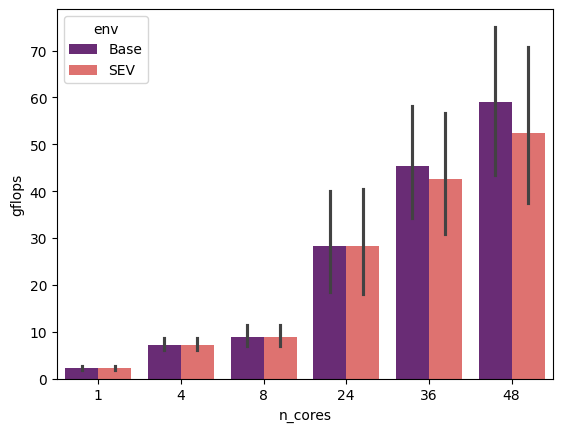

In [12]:
sns.barplot(data=df_med[df_med['config'] == 'OPTIMIZED'], x='n_cores', y='gflops', hue='env', palette='magma')

<Axes: xlabel='n_cores', ylabel='gflops'>

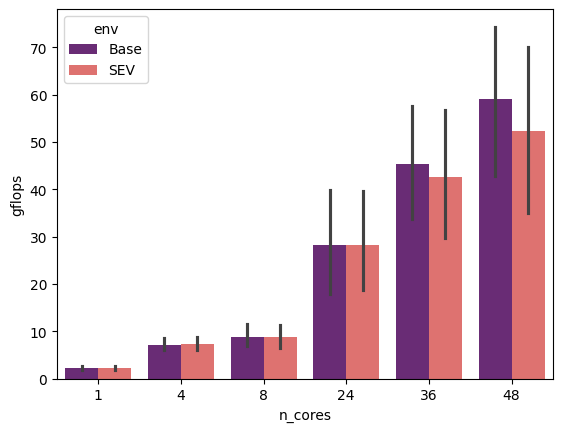

In [13]:
sns.barplot(data=df_med[df_med["config"] == "OPTIMIZED"], x='n_cores', y='gflops', hue='env', palette='magma')

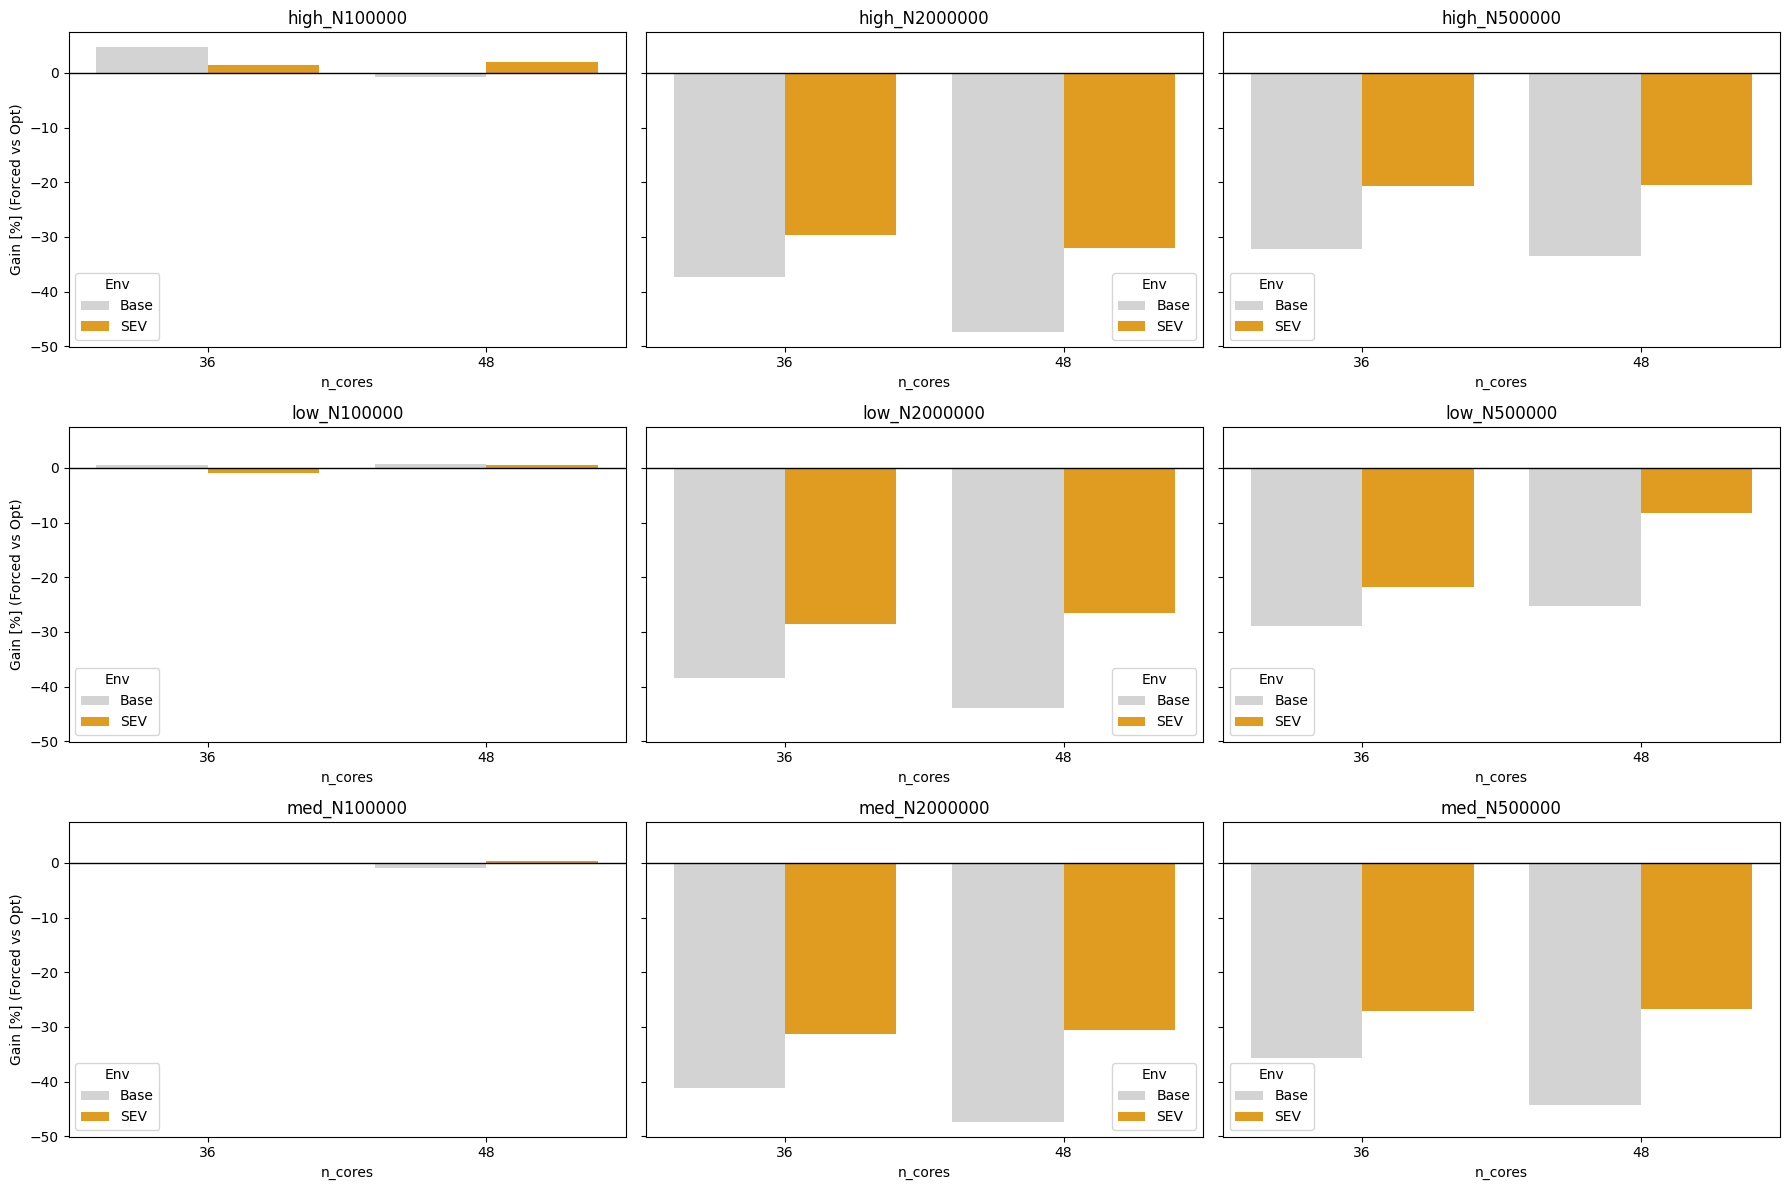

In [11]:
# =========================
# PLOT: Strategie-Vergleich Base vs SEV (> 24 Cores)
# =========================

# 1. Pivot für beide Envs gleichzeitig
df_comp = df_med[df_med['n_cores'] > 24].pivot_table(
    index=['matrix', 'n_cores', 'env'], columns='config', values='gflops'
).reset_index()

# 2. Gain berechnen (FORCED_LOCAL relativ zu OPTIMIZED)
df_comp['gain_pct'] = (df_comp['FORCED_LOCAL'] - df_comp['OPTIMIZED']) / df_comp['OPTIMIZED'] * 100

# 3. Plotten
fig3, axes3 = plt.subplots((len(matrices)+2)//3, 3, figsize=(18, 12), sharey=True)
axes3 = axes3.flatten()

for i, mat in enumerate(matrices):
    sub = df_comp[df_comp['matrix'] == mat]
    if not sub.empty:
        # Gruppierter Barplot: Base vs SEV nebeneinander
        sns.barplot(data=sub, x='n_cores', y='gain_pct', hue='env', 
                    ax=axes3[i], palette={'Base': 'lightgrey', 'SEV': 'orange'})
        
        axes3[i].axhline(0, color='black', lw=1)
        axes3[i].set_title(f"{mat}")
        axes3[i].set_ylabel("Gain [%] (Forced vs Opt)")
        axes3[i].legend(title="Env")
    else:
        axes3[i].axis('off')

plt.tight_layout()
plt.show()